<a href="https://colab.research.google.com/github/MylesB97/ID_Card_Tampering/blob/creating-ID-Tampering-Detector/ID_Card_Tampering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
from google.colab import userdata

In [71]:
!git config --global user.email "user.email"
!git config --global user.name "MylesB97"
!git config --global user.password "user.password"

In [103]:
token = 'token'
!git pull https://{token}@github.com/MylesB97/ID_Card_Tampering.git

From https://github.com/MylesB97/ID_Card_Tampering
 * branch            HEAD       -> FETCH_HEAD
Already up to date.


In [58]:
%ls

ID_Card_Tampering.ipynb  photos/  README.md


In [99]:
!git switch -c creating-ID-Tampering-Detector

Switched to a new branch 'creating-ID-Tampering-Detector'


In [104]:
!git add . --all

In [105]:
!git status

On branch creating-ID-Tampering-Detector
nothing to commit, working tree clean


In [106]:
!git commit -m "added photos to file"

On branch creating-ID-Tampering-Detector
nothing to commit, working tree clean


In [107]:
!git remote -v

origin	https://token@github.com/MylesB97/ID_Card_Tampering.git (fetch)
origin	https://token@github.com/MylesB97/ID_Card_Tampering.git (push)


In [110]:
!git push origin creating-ID-Tampering-Detector

error: src refspec token=token does not match any
error: failed to push some refs to 'https://github.com/MylesB97/ID_Card_Tampering.git'


# ID Card Tampering App


For this project we will first need to calculate structural similarity of original ID Card and the ID Card uploaded by the user.

In [16]:
# Importing the Necessary packages
from skimage.metrics import structural_similarity
import imutils
import cv2
from PIL import Image
import requests

In [123]:
#Getting Image Data
original = Image.open(requests.get('https://www.thestatesman.com/wp-content/uploads/2019/07/pan-card.jpg', stream=True).raw)
tampered = Image.open(requests.get('https://assets1.cleartax-cdn.com/s/img/20170526124335/Pan4.png', stream=True).raw)

## Loading Images Provided


In [18]:
# Format of source files
print(original.format)
print(tampered.format)

JPEG
PNG


In [126]:
# Size of source files
print(original.size)
print(tampered.size)

(1200, 800)
(282, 179)


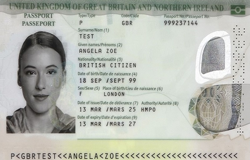

In [129]:
UKPassportResized

# Converting image format and size to match

In [55]:
import os

# Resize Images
original = original.resize((250, 160))
tampered = tampered.resize((250, 160))

# Ensure the directory exists before saving
os.makedirs('photos', exist_ok=True)

original.save('photos/original.png')
tampered.save('photos/tampered.png')

In [73]:
print(original.size)
print(tampered.size)

(250, 160)
(250, 160)


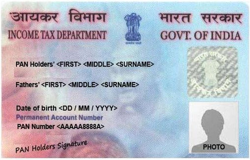

In [74]:
original

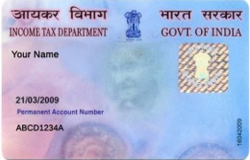

In [75]:
tampered

In [117]:
#Loads image and automatically makes it greyscale
originalCV = cv2.cvtColor(cv2.imread('photos/original.png'), cv2.COLOR_BGR2GRAY)
tamperedCV = cv2.cvtColor(cv2.imread('photos/tampered.png'), cv2.COLOR_BGR2GRAY)

The images are converted to grayscale to simplify the proccessing done by the sscore similarity checker. It reduces the colour channels from 3 (RGB) to 1 and so it can focus on determining the difference between edges of colour changes

array([[254, 254, 253, ..., 253, 253, 254],
       [254, 251, 249, ..., 248, 249, 252],
       [253, 249, 252, ..., 249, 247, 251],
       ...,
       [249, 229, 217, ..., 190, 200, 238],
       [251, 248, 246, ..., 238, 241, 247],
       [253, 254, 253, ..., 255, 254, 253]], dtype=uint8)
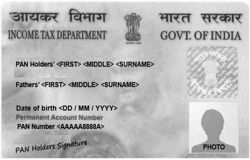

In [118]:
originalCV

array([[254, 254, 254, ..., 252, 252, 254],
       [254, 254, 254, ..., 251, 251, 253],
       [254, 254, 250, ..., 238, 252, 252],
       ...,
       [253, 255, 250, ..., 236, 251, 252],
       [254, 253, 253, ..., 248, 253, 253],
       [255, 254, 254, ..., 253, 253, 250]], dtype=uint8)
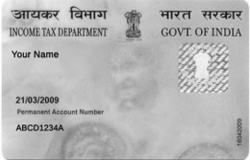

In [119]:
tamperedCV

In [120]:
(score,diff) = structural_similarity(originalCV,tamperedCV,full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(score))

SSIM: 0.31686135690489126


Structual Similarity helps us to determine exactly where in terms of x,y coordinates of the two images differ. In the example aboce we are loooking for the similarity between them so the higher the outputted score the more similar they are.

The outputs for this function are a score as discussed above and the full SSIM image. shown below

array([[215, 208, 191, ...,  91,  87,  91],
       [214, 215, 204, ..., 121, 119, 111],
       [218, 221, 218, ..., 150, 148, 140],
       ...,
       [183, 199, 198, ..., 179, 183, 193],
       [174, 190, 178, ..., 156, 167, 183],
       [149, 179, 171, ..., 141, 149, 156]], dtype=uint8)
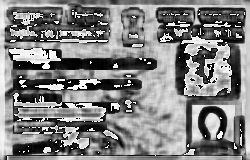

In [132]:
diff

In [130]:
#Threshold and Contours
thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

In the cell above the threshold function was used to create a form array. Thus changing the image from a grayscale to a binary image.

This change was to enable the use of contours which are useful for shape analysis and recognition.

Find contours works on the binary image to retrieve the contours and grab contours stores the values generated

In [ ]:
#loop over contours
for c in cnts:
  (x,y,w,h) = cv2.boundingRect(c)
  cv2.rectangle(originalCV,(x,y),(x+w,y+h),(0,0,255),2)
  cv2.rectangle(tamperedCV,(x,y),(x+w,y+h),(0,0,255),2)

Bounding rectangle helps in finding the ratio of the width to height of the rectangle of the object